# Notebook 04: Inclusion-Inclusion Interaction Energy

Quantifies elastic interaction between multiple inclusions as a function of
array geometry and size.

**Interaction energy:** $E_\text{int} = E_\text{total} - N E_0$

where $E_0$ is the self-energy of a single isolated inclusion and $N$ is the
inclusion count. Negative $E_\text{int}$ indicates cooperative elastic relaxation.

**Two analyses:**
1. NxN uniform grids — interaction energy vs. array size
2. Directional lines (horizontal, diagonal 1, diagonal 2) — geometry dependence

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
import sys
sys.path.append("../src")
from elasticity_utils import build_greens_function, generate_inclusion_mask, compute_strain_and_energy

plt.rcParams["font.family"] = "Helvetica"

GRID_SIZE = 1024
INCLUSION_RADIUS = 4
MU, NU = 1.0, 0.25
EIGENSTRAIN = (0.005691, 0.005691, -2.92e-07)  # 2FeTi + V_O

Gxx, Gxy, Gyy = build_greens_function(GRID_SIZE, MU, NU)

# Single-inclusion self-energy (reference)
center = (GRID_SIZE // 2, GRID_SIZE // 2)
exx0, eyy0, exy0 = generate_inclusion_mask([center], GRID_SIZE, INCLUSION_RADIUS, EIGENSTRAIN)
_, _, _, E0, _ = compute_strain_and_energy(exx0, eyy0, exy0, Gxx, Gxy, Gyy, MU, NU)
print(f"Single inclusion self-energy E0 = {E0:.6e}")

Single inclusion self-energy E0 = 1.549607e-02


In [7]:
def make_grid_positions(n, grid_size, inclusion_radius):
    """Place N×N inclusions in a uniform grid centered on the domain."""
    spacing = (grid_size - 2 * inclusion_radius) // (n + 1)
    start = inclusion_radius + spacing
    positions = []
    for i in range(n):
        for j in range(n):
            r = start + i * spacing
            c = start + j * spacing
            positions.append((r, c))
    return positions

array_sizes = [3, 5, 9, 15, 20, 25]
E_int_grid = []

for n in array_sizes:
    positions = make_grid_positions(n, GRID_SIZE, INCLUSION_RADIUS)
    N = len(positions)
    exx, eyy, exy = generate_inclusion_mask(positions, GRID_SIZE, INCLUSION_RADIUS, EIGENSTRAIN)
    _, _, _, E_total, _ = compute_strain_and_energy(exx, eyy, exy, Gxx, Gxy, Gyy, MU, NU)
    E_int = E_total - N * E0
    E_int_grid.append(E_int)
    print(f"{n}x{n} ({N} inclusions): E_int = {E_int:.4f}")

3x3 (9 inclusions): E_int = -0.0159
5x5 (25 inclusions): E_int = -0.0704
9x9 (81 inclusions): E_int = -0.3148
15x15 (225 inclusions): E_int = -1.0104
20x20 (400 inclusions): E_int = -1.8655
25x25 (625 inclusions): E_int = -3.6936


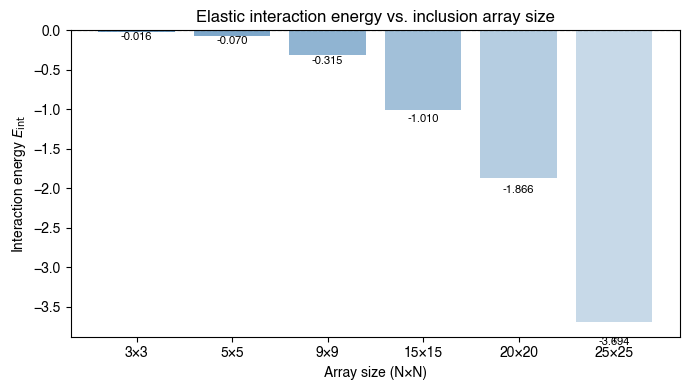

In [8]:
labels = [f"{n}×{n}" for n in array_sizes]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, E_int_grid, color=[
    mcolors.to_rgba("steelblue", alpha=0.8 - 0.1 * i) for i in range(len(labels))
])
for i, v in enumerate(E_int_grid):
    ax.text(i, v - 0.05 * abs(v), f"{v:.3f}", ha="center", va="top", fontsize=8)
ax.set_xlabel("Array size (N×N)")
ax.set_ylabel("Interaction energy $E_\\mathrm{int}$")
ax.set_title("Elastic interaction energy vs. inclusion array size")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.savefig("../figures/interaction_energy_grid_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
def make_line_positions(n, orientation, grid_size, inclusion_radius):
    """
    Place n inclusions in a line across the grid center.

    Parameters
    ----------
    orientation : str — 'horizontal', 'diagonal1' (negative slope), 
                        or 'diagonal2' (positive slope)
    """
    center = grid_size // 2
    spacing = (grid_size - 4 * inclusion_radius) // (n + 1)
    offsets = np.arange(n) - (n - 1) / 2
    offsets = (offsets * spacing).astype(int)

    positions = []
    for d in offsets:
        if orientation == 'horizontal':
            positions.append((center, center + d))
        elif orientation == 'diagonal1':   # negative slope: row increases as col increases
            positions.append((center + d, center + d))
        elif orientation == 'diagonal2':   # positive slope: row decreases as col increases
            positions.append((center - d, center + d))
    return positions


counts = [3, 5, 9]
orientations = ['horizontal', 'diagonal1', 'diagonal2']
orient_labels = ['Horizontal', 'Diagonal 1', 'Diagonal 2']

# Use a smaller grid for the directional study (128 is sufficient)
GRID_SIZE_DIR = 128
Gxx_d, Gxy_d, Gyy_d = build_greens_function(GRID_SIZE_DIR, MU, NU)

# Single-inclusion self-energy on this grid
center_d = (GRID_SIZE_DIR // 2, GRID_SIZE_DIR // 2)
exx0_d, eyy0_d, exy0_d = generate_inclusion_mask(
    [center_d], GRID_SIZE_DIR, INCLUSION_RADIUS, EIGENSTRAIN
)
_, _, _, E0_d, _ = compute_strain_and_energy(
    exx0_d, eyy0_d, exy0_d, Gxx_d, Gxy_d, Gyy_d, MU, NU
)

# Compute interaction energies
results = []
for orient, label in zip(orientations, orient_labels):
    for n in counts:
        positions = make_line_positions(n, orient, GRID_SIZE_DIR, INCLUSION_RADIUS)
        exx, eyy, exy = generate_inclusion_mask(
            positions, GRID_SIZE_DIR, INCLUSION_RADIUS, EIGENSTRAIN
        )
        _, _, _, E_total, _ = compute_strain_and_energy(
            exx, eyy, exy, Gxx_d, Gxy_d, Gyy_d, MU, NU
        )
        E_int = E_total - n * E0_d
        results.append({'Orientation': label, 'Count': n, 'E_int': E_int})
        print(f"{label:12s} n={n}: E_int = {E_int:.4e}")

df_directional = pd.DataFrame(results)

Horizontal   n=3: E_int = 2.9559e-03
Horizontal   n=5: E_int = 1.7912e-02
Horizontal   n=9: E_int = 8.4582e-02
Diagonal 1   n=3: E_int = -4.7302e-03
Diagonal 1   n=5: E_int = -8.6004e-03
Diagonal 1   n=9: E_int = -1.1117e-02
Diagonal 2   n=3: E_int = 2.0937e-04
Diagonal 2   n=5: E_int = 8.4477e-03
Diagonal 2   n=9: E_int = 4.9336e-02


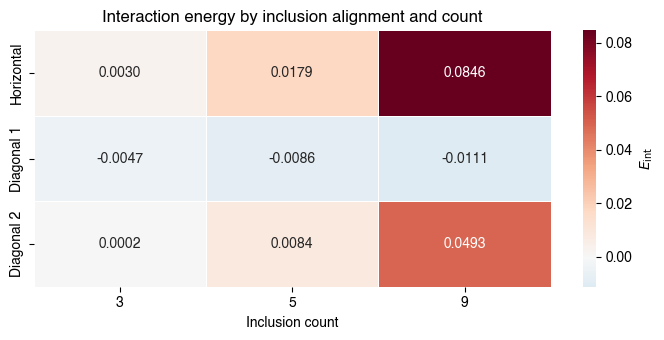

In [11]:
heatmap_data = df_directional.pivot(index="Orientation", columns="Count", values="E_int")
heatmap_data = heatmap_data.loc[["Horizontal", "Diagonal 1", "Diagonal 2"]]

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "$E_\\mathrm{int}$"})
ax.set_title("Interaction energy by inclusion alignment and count")
ax.set_xlabel("Inclusion count")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../figures/interaction_energy_directional.png", dpi=150, bbox_inches="tight")
plt.show()